# RL Project: Atari Tennis Tournament

This notebook implements four Reinforcement Learning algorithms to play Atari Tennis (`ALE/Tennis-v5` via Gymnasium):

1. **SARSA** — Semi-gradient SARSA with linear approximation (inspired by Lab 7, on-policy update from Lab 5B)
2. **Q-Learning** — Off-policy linear approximation (inspired by Lab 5B)

Each agent is **pre-trained independently** against the built-in Atari AI opponent, then evaluated in a comparative tournament.

In [51]:
import pickle
from collections import deque
from pathlib import Path

import ale_py  # noqa: F401 — registers ALE environments
from pettingzoo.atari import tennis_v3
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import numpy as np

import torch
from torch import nn, optim


# Configuration & Checkpoints

We use a **checkpoint** system (`pickle` serialization) to save and restore trained agent weights. This enables an incremental workflow:
- Train one agent at a time and save its weights
- Resume later without retraining previous agents
- Load all checkpoints for the final evaluation

In [52]:
CHECKPOINT_DIR = Path("checkpoints")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)


def get_path(name: str) -> Path:
    """Return the checkpoint path for an agent (.pkl)."""
    base = name.lower().replace(" ", "_").replace("-", "_")
    return CHECKPOINT_DIR / (base + ".pkl")


# Utility Functions

## Observation Normalization

The Tennis environment produces image observations of shape `(4, 84, 84)` after preprocessing (grayscale + resize + frame stack).
We normalize them into 1D `float64` vectors divided by 255, as in Lab 7 (continuous feature normalization).

## ε-greedy Policy

Follows the pattern from Lab 5B (`epsilon_greedy`) and Lab 7 (`epsilon_greedy_action`):
- With probability ε: random action (exploration)
- With probability 1−ε: action maximizing $\hat{q}(s, a)$ with uniform tie-breaking (`np.flatnonzero`)

In [53]:
def normalize_obs(observation: np.ndarray) -> np.ndarray:
    """Flatten and normalize an observation to a 1D float64 vector.

    Args:
        observation: Raw observation array from the environment.

    Returns:
        1D numpy array of dtype float64, values in [0, 1].

    """
    return observation.flatten().astype(np.float64) / 255.0


def epsilon_greedy(
    q_values: np.ndarray,
    epsilon: float,
    rng: np.random.Generator,
) -> int:
    """Select an action using an ε-greedy policy with fair tie-breaking.

    Follows the same logic as Lab 5B epsilon_greedy and Lab 7 epsilon_greedy_action:
    - With probability epsilon: choose a random action (exploration).
    - With probability 1-epsilon: choose the action with highest Q-value (exploitation).
    - If multiple actions share the maximum Q-value, break ties uniformly at random.

    Handles edge cases: empty q_values, NaN/Inf values.

    Args:
        q_values: Array of Q-values for each action, shape (n_actions,).
        epsilon: Exploration probability in [0, 1].
        rng: NumPy random number generator.

    Returns:
        Selected action index.

    """
    q_values = np.asarray(q_values, dtype=np.float64).reshape(-1)

    if q_values.size == 0:
        msg = "q_values is empty."
        raise ValueError(msg)

    if rng.random() < epsilon:
        return int(rng.integers(0, q_values.size))

    finite_mask = np.isfinite(q_values)
    if not np.any(finite_mask):
        return int(rng.integers(0, q_values.size))

    safe_q = q_values.copy()
    safe_q[~finite_mask] = -np.inf
    max_val = np.max(safe_q)
    best = np.flatnonzero(safe_q == max_val)

    if best.size == 0:
        return int(rng.integers(0, q_values.size))

    return int(rng.choice(best))


# Agent Definitions

## Base Class `Agent`

Common interface for all agents, same signatures: `get_action`, `update`, `save`, `load`.
Serialization uses `pickle` (compatible with numpy arrays).

In [54]:
class Agent:
    """Base class for reinforcement learning agents.

    All agents share this interface so they are compatible with the tournament system.
    """

    def __init__(self, seed: int, action_space: int) -> None:
        """Initialize the agent with its action space and a reproducible RNG."""
        self.action_space = action_space
        self.rng = np.random.default_rng(seed=seed)

    def get_action(self, observation: np.ndarray, epsilon: float = 0.0) -> int:
        """Select an action from the current observation."""
        raise NotImplementedError

    def update(
        self,
        state: np.ndarray,
        action: int,
        reward: float,
        next_state: np.ndarray,
        done: bool,
        next_action: int | None = None,
        agent_id: str = "single",
    ) -> None:
        """Update the agent's internal state based on a transition."""

    def save(self, filename: str) -> None:
        """Save the agent state to disk using pickle."""
        with Path(filename).open("wb") as f:
            pickle.dump(self.__dict__, f)

    def load(self, filename: str) -> None:
        """Load the agent state from disk."""
        with Path(filename).open("rb") as f:
            path = Path(filename).resolve()
            ckpt_root = CHECKPOINT_DIR.resolve()
            if ckpt_root not in path.parents:
                msg = f"Refusing to load checkpoint outside '{ckpt_root}': {path}"
                raise ValueError(msg)
            if path.suffix != ".pkl":
                msg = f"Unsupported checkpoint format: {path.suffix}"
                raise ValueError(msg)

            state = pickle.load(f)  # noqa: S301 - trusted local checkpoints only
            if not isinstance(state, dict):
                msg = "Invalid checkpoint payload: expected a dict."
                raise TypeError(msg)

            self.__dict__.update(state)


## Random Agent (baseline)

Serves as a reference to evaluate the performance of learning agents.

In [55]:
class RandomAgent(Agent):
    """A simple agent that selects actions uniformly at random (baseline)."""

    def get_action(self, observation: np.ndarray, epsilon: float = 0.0) -> int:
        """Select a random action, ignoring the observation and epsilon."""
        _ = observation, epsilon
        return int(self.rng.integers(0, self.action_space))


## SARSA Agent — Linear Approximation (Semi-gradient)

This agent combines:
- **Linear approximation** from Lab 7 (`SarsaAgent`): $\hat{q}(s, a; \mathbf{W}) = \mathbf{W}_a^\top \phi(s)$
- **On-policy SARSA update** from Lab 5B (`train_sarsa`): $\delta = r + \gamma \hat{q}(s', a') - \hat{q}(s, a)$

The semi-gradient update rule is:
$$W_a \leftarrow W_a + \alpha \cdot \delta \cdot \phi(s)$$

where $\phi(s)$ is the normalized observation vector (analogous to tile coding features in Lab 7, but in dense form).

In [56]:
class SarsaAgent(Agent):
    """Semi-gradient SARSA agent with linear function approximation.

    Inspired by:
    - Lab 7 SarsaAgent: linear q(s,a) = W_a . phi(s), semi-gradient update
    - Lab 5B train_sarsa: on-policy TD target using Q(s', a')

    The weight matrix W has shape (n_actions, n_features).
    For a given state s, q(s, a) = W[a] @ phi(s) is the dot product
    of the action's weight row with the normalized observation.
    """

    def __init__(
        self,
        n_features: int,
        n_actions: int,
        alpha: float = 0.001,
        gamma: float = 0.99,
        seed: int = 42,
    ) -> None:
        """Initialize SARSA agent with linear weights.

        Args:
            n_features: Dimension of the feature vector phi(s).
            n_actions: Number of discrete actions.
            alpha: Learning rate (kept small for high-dim features).
            gamma: Discount factor.
            seed: RNG seed for reproducibility.

        """
        super().__init__(seed, n_actions)
        self.n_features = n_features
        self.alpha = alpha
        self.gamma = gamma
        self.W = np.zeros((n_actions, n_features), dtype=np.float64)

    def _q_values(self, phi: np.ndarray) -> np.ndarray:
        """Compute Q-values for all actions given feature vector phi(s).

        Equivalent to Lab 7's self.q(s, a) = self.w[idx].sum()
        but using dense linear approximation: q(s, a) = W[a] @ phi.

        Args:
            phi: Normalized feature vector, shape (n_features,).

        Returns:
            Array of Q-values, shape (n_actions,).

        """
        return self.W @ phi

    def get_action(self, observation: np.ndarray, epsilon: float = 0.0) -> int:
        """Select action using ε-greedy policy over linear Q-values.

        Same pattern as Lab 7 SarsaAgent.eps_greedy:
        compute q-values for all actions, then apply epsilon_greedy.
        """
        phi = normalize_obs(observation)
        q_vals = self._q_values(phi)
        return epsilon_greedy(q_vals, epsilon, self.rng)

    def update(
        self,
        state: np.ndarray,
        action: int,
        reward: float,
        next_state: np.ndarray,
        done: bool,
        next_action: int | None = None,
        agent_id: str = "single",
    ) -> None:
        """Perform one semi-gradient SARSA update.

        Follows the SARSA update from Lab 5B train_sarsa:
            td_target = r + gamma * Q(s', a') * (0 if done else 1)
            Q(s, a) += alpha * (td_target - Q(s, a))

        In continuous form with linear approximation (Lab 7 SarsaAgent.update):
            delta = target - q(s, a)
            W[a] += alpha * delta * phi(s)
        """
        phi = np.nan_to_num(normalize_obs(state), nan=0.0, posinf=0.0, neginf=0.0)
        q_sa = float(self.W[action] @ phi)
        if not np.isfinite(q_sa):
            q_sa = 0.0

        if done:
            target = reward
        else:
            phi_next = np.nan_to_num(
                normalize_obs(next_state), nan=0.0, posinf=0.0, neginf=0.0,
            )
            if next_action is None:
                next_action = 0
            q_sp_ap = float(self.W[next_action] @ phi_next)
            if not np.isfinite(q_sp_ap):
                q_sp_ap = 0.0
            target = float(reward) + self.gamma * q_sp_ap

        if not np.isfinite(target):
            return

        delta = float(target - q_sa)
        if not np.isfinite(delta):
            return

        td_step = float(np.clip(delta, -1_000.0, 1_000.0))
        self.W[action] += self.alpha * td_step * phi
        self.W[action] = np.nan_to_num(self.W[action], nan=0.0, posinf=1e6, neginf=-1e6)


## Q-Learning Agent — Linear Approximation (Off-policy)

Same architecture as SARSA but with the **off-policy update** from Lab 5B (`train_q_learning`):

$$\delta = r + \gamma \max_{a'} \hat{q}(s', a') - \hat{q}(s, a)$$

The key difference from SARSA: we use $\max_{a'} Q(s', a')$ instead of $Q(s', a')$ where $a'$ is the action actually chosen. This allows learning the optimal policy independently of the exploration policy.

In [57]:
class QLearningAgent(Agent):
    """Q-Learning agent with linear function approximation (off-policy).

    Inspired by:
    - Lab 5B train_q_learning: off-policy TD target using max_a' Q(s', a')
    - Lab 7 SarsaAgent: linear approximation q(s,a) = W[a] @ phi(s)

    The only difference from SarsaAgent is the TD target:
    SARSA uses Q(s', a') (on-policy), Q-Learning uses max_a' Q(s', a') (off-policy).
    """

    def __init__(
        self,
        n_features: int,
        n_actions: int,
        alpha: float = 0.001,
        gamma: float = 0.99,
        seed: int = 42,
    ) -> None:
        """Initialize Q-Learning agent with linear weights.

        Args:
            n_features: Dimension of the feature vector phi(s).
            n_actions: Number of discrete actions.
            alpha: Learning rate.
            gamma: Discount factor.
            seed: RNG seed.

        """
        super().__init__(seed, n_actions)
        self.n_features = n_features
        self.alpha = alpha
        self.gamma = gamma
        self.W = np.zeros((n_actions, n_features), dtype=np.float64)

    def _q_values(self, phi: np.ndarray) -> np.ndarray:
        """Compute Q-values for all actions: q(s, a) = W[a] @ phi for each a."""
        return self.W @ phi

    def get_action(self, observation: np.ndarray, epsilon: float = 0.0) -> int:
        """Select action using ε-greedy policy over linear Q-values."""
        phi = normalize_obs(observation)
        q_vals = self._q_values(phi)
        return epsilon_greedy(q_vals, epsilon, self.rng)

    def update(
        self,
        state: np.ndarray,
        action: int,
        reward: float,
        next_state: np.ndarray,
        done: bool,
        next_action: int | None = None,
        agent_id: str = "single",
    ) -> None:
        """Perform one Q-learning update.

        Follows Lab 5B train_q_learning:
            td_target = r + gamma * max(Q[s2]) * (0 if terminated else 1)
            Q[s, a] += alpha * (td_target - Q[s, a])

        In continuous form with linear approximation:
            delta = target - q(s, a)
            W[a] += alpha * delta * phi(s)
        """
        _ = next_action
        phi = np.nan_to_num(normalize_obs(state), nan=0.0, posinf=0.0, neginf=0.0)
        q_sa = float(self.W[action] @ phi)
        if not np.isfinite(q_sa):
            q_sa = 0.0

        if done:
            target = reward
        else:
            phi_next = np.nan_to_num(
                normalize_obs(next_state), nan=0.0, posinf=0.0, neginf=0.0,
            )
            q_next_all = self._q_values(phi_next)
            q_next_max = float(np.max(q_next_all))
            if not np.isfinite(q_next_max):
                q_next_max = 0.0
            target = float(reward) + self.gamma * q_next_max

        if not np.isfinite(target):
            return

        delta = float(target - q_sa)
        if not np.isfinite(delta):
            return

        td_step = float(np.clip(delta, -1_000.0, 1_000.0))
        self.W[action] += self.alpha * td_step * phi
        self.W[action] = np.nan_to_num(self.W[action], nan=0.0, posinf=1e6, neginf=-1e6)


## Monte Carlo Agent — Linear Approximation (First-visit)

This agent is inspired by Lab 4 (`mc_control_epsilon_soft`):
- Accumulates transitions in an episode buffer `(state, action, reward)`
- At the end of the episode (`done=True`), computes **cumulative returns** by traversing the buffer backward:
  $$G \leftarrow \gamma \cdot G + r$$
- Updates weights with the semi-gradient rule:
  $$W_a \leftarrow W_a + \alpha \cdot (G - \hat{q}(s, a)) \cdot \phi(s)$$

Unlike TD methods (SARSA, Q-Learning), Monte Carlo waits for the complete episode to finish before updating.

> **Note**: This agent currently has **checkpoint loading issues** — the saved weights fail to restore properly, causing the agent to behave as if untrained during evaluation. The training code itself works correctly.

In [58]:
class MonteCarloAgent(Agent):
    """Monte Carlo control agent with linear function approximation."""

    def __init__(
        self,
        n_features: int,
        n_actions: int,
        alpha: float = 0.001,
        gamma: float = 0.99,
        seed: int = 42,
    ) -> None:
        """Initialize Monte Carlo agent with linear weights and episode buffers."""
        super().__init__(seed, n_actions)
        self.n_features = n_features
        self.alpha = alpha
        self.gamma = gamma
        self.W = np.zeros((n_actions, n_features), dtype=np.float32)
        self._obs_buf: dict[str, list[np.ndarray]] = {}
        self._act_buf: dict[str, list[int]] = {}
        self._rew_buf: dict[str, list[float]] = {}

    def _q_values(self, phi: np.ndarray) -> np.ndarray:
        """Compute Q-values."""
        return self.W @ phi

    def get_action(self, observation: np.ndarray, epsilon: float = 0.0) -> int:
        """Select action using epsilon-greedy policy over linear Q-values."""
        phi = observation.flatten().astype(np.float32) / np.float32(255.0)
        q_vals = self._q_values(phi)
        return epsilon_greedy(q_vals, epsilon, self.rng)

    def update(
        self,
        state: np.ndarray,
        action: int,
        reward: float,
        next_state: np.ndarray,
        done: bool,
        next_action: int | None = None,
        agent_id: str = "single",
    ) -> None:
        """Accumulate episode transitions and update weights at episode end."""
        _ = next_state, next_action

        if agent_id not in self._obs_buf:
            self._obs_buf[agent_id] = []
            self._act_buf[agent_id] = []
            self._rew_buf[agent_id] = []

        self._obs_buf[agent_id].append(state)
        self._act_buf[agent_id].append(action)
        self._rew_buf[agent_id].append(reward)

        if not done:
            return

        n = len(self._rew_buf[agent_id])
        actions = np.array(self._act_buf[agent_id], dtype=np.intp)

        returns = np.empty(n, dtype=np.float32)
        G = np.float32(0.0)
        gamma32 = np.float32(self.gamma)
        for i in range(n - 1, -1, -1):
            G = gamma32 * G + np.float32(self._rew_buf[agent_id][i])
            returns[i] = G

        alpha32 = np.float32(self.alpha)
        chunk_size = 500
        for start in range(0, n, chunk_size):
            end = min(start + chunk_size, n)
            cs = end - start

            raw = np.array(self._obs_buf[agent_id][start:end])
            phi = raw.reshape(cs, -1).astype(np.float32)
            phi /= np.float32(255.0)

            ca = actions[start:end]
            q_sa = np.einsum("ij,ij->i", self.W[ca], phi)

            deltas = np.clip(returns[start:end] - q_sa, -1000.0, 1000.0)

            for a in range(self.action_space):
                mask = ca == a
                if not np.any(mask):
                    continue
                self.W[a] += alpha32 * (deltas[mask] @ phi[mask])

        self.W = np.nan_to_num(self.W, nan=0.0, posinf=1e6, neginf=-1e6)

        self._obs_buf[agent_id].clear()
        self._act_buf[agent_id].clear()
        self._rew_buf[agent_id].clear()

    def save(self, filename: str) -> None:
        """Save agent state, clearing episode buffers first to avoid stale data."""
        self._obs_buf.clear()
        self._act_buf.clear()
        self._rew_buf.clear()
        super().save(filename)

    def load(self, filename: str) -> None:
        """Load agent state and ensure correct dtype for weights."""
        super().load(filename)
        self.W = np.asarray(self.W, dtype=np.float32)
        self._obs_buf = {}
        self._act_buf = {}
        self._rew_buf = {}


## DQN Agent — PyTorch MLP with Experience Replay and Target Network

This agent implements the Deep Q-Network (DQN) using **PyTorch** for GPU-accelerated training (MPS on Apple Silicon).

**Network architecture** (same structure as before, now as `torch.nn.Module`):
$$\text{Input}(n\_features) \to \text{Linear}(256) \to \text{ReLU} \to \text{Linear}(256) \to \text{ReLU} \to \text{Linear}(n\_actions)$$

**Key techniques** (inspired by Lab 6A Dyna-Q + classic DQN):
- **Experience Replay**: circular buffer of transitions, sampled as minibatches for off-policy updates
- **Target Network**: periodically synchronized copy of the Q-network, stabilizes learning
- **Gradient clipping**: prevents exploding gradients in deep networks
- **GPU acceleration**: tensors on MPS/CUDA device for fast forward/backward passes

> **Note**: This agent currently has **checkpoint loading issues** — the saved `.pt` checkpoint fails to restore properly (device mismatch / state dict incompatibility), causing errors during evaluation. The training code itself works correctly.

In [59]:
class QNetwork(nn.Module):
    """MLP Q-network: Input -> 256 -> ReLU -> 256 -> ReLU -> n_actions."""

    def __init__(self, n_features: int, n_actions: int) -> None:
        """Initialize the Q-network architecture."""
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, n_actions),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Compute Q-values for input state tensor x."""
        return self.net(x)


class ReplayBuffer:
    """Fixed-size circular replay buffer storing (s, a, r, s', done) transitions."""

    def __init__(self, capacity: int) -> None:
        """Initialize the replay buffer with a maximum capacity."""
        self.buffer: deque[tuple[np.ndarray, int, float, np.ndarray, bool]] = deque(maxlen=capacity)

    def push(self, state: np.ndarray, action: int, reward: float, next_state: np.ndarray, done: bool) -> None:
        """Add a transition to the replay buffer."""
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size: int, rng: np.random.Generator) -> tuple[np.ndarray, ...]:
        """Sample a random minibatch of transitions from the buffer."""
        indices = rng.choice(len(self.buffer), size=batch_size, replace=False)
        batch = [self.buffer[i] for i in indices]
        states = np.array([t[0] for t in batch])
        actions = np.array([t[1] for t in batch])
        rewards = np.array([t[2] for t in batch])
        next_states = np.array([t[3] for t in batch])
        dones = np.array([t[4] for t in batch], dtype=np.float32)
        return states, actions, rewards, next_states, dones

    def __len__(self) -> int:
        """Return the current number of transitions stored in the buffer."""
        return len(self.buffer)


class DQNAgent(Agent):
    """Deep Q-Network agent using PyTorch with GPU acceleration (MPS/CUDA).

    Inspired by:
    - Lab 6A Dyna-Q: experience replay (store transitions, sample for updates)
    - Classic DQN (Mnih et al., 2015): target network, minibatch SGD

    Uses Adam optimizer and Huber loss (smooth L1) for stable training.
    """

    def __init__(
        self,
        n_features: int,
        n_actions: int,
        lr: float = 1e-4,
        gamma: float = 0.99,
        buffer_size: int = 50_000,
        batch_size: int = 64,
        target_update_freq: int = 1000,
        train_freq: int = 4,
        seed: int = 42,
    ) -> None:
        """Initialize DQN agent.

        Args:
            n_features: Input feature dimension.
            n_actions: Number of discrete actions.
            lr: Learning rate for Adam optimizer.
            gamma: Discount factor.
            buffer_size: Maximum replay buffer capacity.
            batch_size: Minibatch size for updates.
            target_update_freq: Steps between target network syncs.
            train_freq: Number of steps between each training update.
            seed: RNG seed.

        """
        super().__init__(seed, n_actions)
        self.n_features = n_features
        self.lr = lr
        self.gamma = gamma
        self.batch_size = batch_size
        self.target_update_freq = target_update_freq
        self.train_freq = train_freq
        self.update_step = 0
        self.train_step = 0

        torch.manual_seed(seed)
        self.device = torch.device("cpu")
        self.q_net = QNetwork(n_features, n_actions).to(self.device)
        self.target_net = QNetwork(n_features, n_actions).to(self.device)
        self.target_net.load_state_dict(self.q_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.q_net.parameters(), lr=lr)
        self.loss_fn = nn.SmoothL1Loss()

        self.replay_buffer = ReplayBuffer(buffer_size)

    def get_action(self, observation: np.ndarray, epsilon: float = 0.0) -> int:
        """Select action using epsilon-greedy policy over Q-network outputs."""
        if self.rng.random() < epsilon:
            return int(self.rng.integers(0, self.action_space))

        phi = normalize_obs(observation)
        with torch.no_grad():
            state_t = torch.from_numpy(phi).float().unsqueeze(0).to(self.device)
            q_vals = self.q_net(state_t).numpy().squeeze(0)
        return epsilon_greedy(q_vals, 0.0, self.rng)

    def update(
        self,
        state: np.ndarray,
        action: int,
        reward: float,
        next_state: np.ndarray,
        done: bool,
        next_action: int | None = None,
        agent_id: str = "single",
    ) -> None:
        """Store transition and perform a minibatch DQN update."""
        _ = next_action

        phi_s = normalize_obs(state)
        phi_sp = normalize_obs(next_state)
        self.replay_buffer.push(phi_s, action, reward, phi_sp, done)

        self.update_step += 1
        # Optimize: only train every `train_freq` steps to save computation
        if (
            len(self.replay_buffer) < self.batch_size
            or self.update_step % self.train_freq != 0
        ):
            return

        states_b, actions_b, rewards_b, next_states_b, dones_b = (
            self.replay_buffer.sample(
                self.batch_size,
                self.rng,
            )
        )

        states_t = torch.from_numpy(states_b).float().to(self.device)
        actions_t = torch.from_numpy(actions_b).long().to(self.device)
        rewards_t = torch.from_numpy(rewards_b).float().to(self.device)
        next_states_t = torch.from_numpy(next_states_b).float().to(self.device)
        dones_t = torch.from_numpy(dones_b).float().to(self.device)

        q_values = self.q_net(states_t)
        q_curr = q_values.gather(1, actions_t.unsqueeze(1)).squeeze(1)

        with torch.no_grad():
            q_next = self.target_net(next_states_t).max(dim=1).values
            targets = rewards_t + (1.0 - dones_t) * self.gamma * q_next

        loss = self.loss_fn(q_curr, targets)
        self.optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.q_net.parameters(), max_norm=10.0)
        self.optimizer.step()

        self.train_step += 1
        if self.train_step % self.target_update_freq == 0:
            self.target_net.load_state_dict(self.q_net.state_dict())

    def save(self, filename: str) -> None:
        """Save agent state using torch.save (networks + optimizer + metadata)."""
        torch.save(
            {
                "q_net": self.q_net.state_dict(),
                "target_net": self.target_net.state_dict(),
                "optimizer": self.optimizer.state_dict(),
                "train_step": self.train_step,
                "n_features": self.n_features,
                "action_space": self.action_space,
                "lr": self.lr,
                "gamma": self.gamma,
                "batch_size": self.batch_size,
                "target_update_freq": self.target_update_freq,
            },
            filename,
        )

    def load(self, filename: str) -> None:
        """Load agent state from a torch checkpoint."""
        checkpoint = torch.load(filename, map_location=self.device, weights_only=False)
        self.q_net.load_state_dict(checkpoint["q_net"])
        self.target_net.load_state_dict(checkpoint["target_net"])
        self.train_step = checkpoint.get("train_step", 0)
        self.optimizer = optim.Adam(self.q_net.parameters(), lr=self.lr)
        self.optimizer.load_state_dict(checkpoint["optimizer"])

        buffer_capacity = self.replay_buffer.buffer.maxlen
        if buffer_capacity is None:
            buffer_capacity = 50_000
        self.replay_buffer = ReplayBuffer(buffer_capacity)


## Tennis Environment

Creation of the Atari Tennis environment via Gymnasium (`ALE/Tennis-v5`) with standard wrappers:
- **Grayscale**: `obs_type="grayscale"` — single-channel observations
- **Resize**: `ResizeObservation(84, 84)` — downscale to 84×84
- **Frame stack**: `FrameStackObservation(4)` — stack 4 consecutive frames

The final observation is an array of shape `(4, 84, 84)`, which flattens to 28,224 features.

The agent plays against the **built-in Atari AI opponent**.

In [60]:
def create_env() -> tennis_v3.env:
    """Create a PettingZoo Tennis environment with grayscale, resized, frame-stacked observations."""
    return tennis_v3.env(obs_type="ram")


## Training & Evaluation Infrastructure

Functions for training and evaluating agents in the single-agent Gymnasium environment:

1. **`train_agent`** — Pre-trains an agent against the built-in AI for a given number of episodes with ε-greedy exploration
2. **`plot_training_curves`** — Plots the training reward history (moving average) for all agents

In [61]:
def train_agent(
    env: tennis_v3.env,
    agent: Agent,
    name: str,
    episodes: int = 5000,
    epsilon_start: float = 1.0,
    epsilon_end: float = 0.05,
    total_decay_steps: int = 500_000,
    max_steps: int = 5000,
) -> dict[str, list[float]]:
    """Train the given agent in the environment and return training history."""
    history = {"avg_rewards": [], "abs_rewards": [], "lengths": []}
    global_step = 0
    pbar = tqdm(range(episodes), desc=f"Training {name}", leave=True)

    for _ep in pbar:
        env.reset()
        last_obs = {}
        last_action = {}
        total_reward = {"first_0": 0.0, "second_0": 0.0}
        steps_in_episode = 0

        for step_idx, agent_id in enumerate(env.agent_iter()):
            if step_idx >= max_steps:
                break

            steps_in_episode = step_idx
            obs, reward, termination, truncation, _info = env.last()
            done = termination or truncation
            obs_arr = np.asarray(obs)

            total_reward[agent_id] += float(reward)

            epsilon = max(
                epsilon_end,
                epsilon_start
                - global_step / total_decay_steps * (epsilon_start - epsilon_end),
            )

            action = None if done else agent.get_action(obs_arr, epsilon=epsilon)

            if agent_id in last_obs:
                agent.update(
                    state=last_obs[agent_id],
                    action=last_action[agent_id],
                    reward=float(reward),
                    next_state=obs_arr,
                    done=done,
                    next_action=action,
                    agent_id=agent_id,
                )

            if action is not None:
                last_obs[agent_id] = obs_arr
                last_action[agent_id] = action
                global_step += 1

            env.step(action)

        history["avg_rewards"].append(
            (total_reward["first_0"] + total_reward["second_0"]) / 2.0,
        )
        history["abs_rewards"].append(abs(total_reward["first_0"]))
        history["lengths"].append(float(steps_in_episode))

        recent_window = 50
        if len(history["avg_rewards"]) >= recent_window:
            recent_avg = np.mean(history["avg_rewards"][-recent_window:])
            pbar.set_postfix(
                avg50=f"{recent_avg:.1f}",
                eps=f"{epsilon:.3f}",
                len=f"{steps_in_episode}",
                steps=f"{global_step}",
            )

    return history

def plot_training_curves(
    training_histories: dict[str, dict[str, list[float]]],
    path: str,
    window: int = 100,
) -> None:
    """Plot training curves for multiple agents, showing average rewards, reward intensity, and episode lengths."""
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 10), sharex=True)

    for name, data in training_histories.items():
        color = AGENT_COLORS.get(name, "#7f8c8d")

        rewards = data["avg_rewards"]
        abs_rewards = data["abs_rewards"]
        if len(rewards) >= window:
            ma_rew = np.convolve(rewards, np.ones(window) / window, mode="valid")
            ma_abs = np.convolve(abs_rewards, np.ones(window) / window, mode="valid")
            x = np.arange(window - 1, len(rewards))

            ax1.plot(x, ma_rew, label=f"{name} (Average)", color=color, linewidth=2)
            ax1.plot(
                x,
                ma_abs,
                label=f"{name} (Intensity)",
                color=color,
                linewidth=1.5,
                linestyle="--",
                alpha=0.6,
            )
            ax1.fill_between(
                x,
                ma_rew - np.std(rewards) * 0.2,
                ma_rew + np.std(rewards) * 0.2,
                color=color,
                alpha=0.1,
            )

        lengths = data["lengths"]
        if len(lengths) >= window:
            ma_len = np.convolve(lengths, np.ones(window) / window, mode="valid")
            ax2.plot(x, ma_len, label=name, color=color, linewidth=2)
            ax2.fill_between(
                x,
                ma_len - np.std(lengths) * 0.2,
                ma_len + np.std(lengths) * 0.2,
                color=color,
                alpha=0.1,
            )

    ax1.set_ylabel(f"Reward (MA {window})", fontsize=12)
    ax1.set_title(
        "Training Rewards & Intensity (Self-Play)", fontsize=14, fontweight="bold",
    )
    ax1.legend(fontsize=9, loc="upper left", ncol=2)
    ax1.grid(alpha=0.3, linestyle="--")
    ax1.axhline(y=0, color="black", linewidth=0.8, alpha=0.4)

    ax2.set_xlabel("Episodes", fontsize=12)
    ax2.set_ylabel(f"Steps per Episode (MA {window})", fontsize=12)
    ax2.set_title(
        "Episode Duration (Stability/Survival)", fontsize=14, fontweight="bold",
    )
    ax2.grid(alpha=0.3, linestyle="--")

    for ax in [ax1, ax2]:
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    fig.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()


## Agent Instantiation & Incremental Training (One Agent at a Time)

**Environment**: `ALE/Tennis-v5` (grayscale, 84×84×4 frames → 28,224 features, 18 actions).

**Agents**:
- **Random** — random baseline (no training needed)
- **SARSA** — linear approximation, semi-gradient TD(0)
- **Q-Learning** — linear approximation, off-policy
- **Monte Carlo** — first-visit MC with linear weights (⚠️ checkpoint loading issues)
- **DQN** — deep Q-network with experience replay and target network (⚠️ `.pt` checkpoint loading issues)

**Workflow**:
1. Train **one** selected agent (`AGENT_TO_TRAIN`)
2. Save its weights to `checkpoints/` (`.pkl` for linear agents, `.pt` for DQN)
3. Repeat later for another agent without retraining previous ones
4. Load all saved checkpoints before the final evaluation

In [72]:
env = create_env()
env.reset()
obs, *_ = env.last()

n_actions = env.action_space("first_0").n
n_features = 128

agent_random = RandomAgent(seed=42, action_space=int(n_actions))
agent_sarsa = SarsaAgent(n_features=n_features, n_actions=n_actions, alpha=1e-4)
agent_q = QLearningAgent(n_features=n_features, n_actions=n_actions, alpha=1e-4)
agent_mc = MonteCarloAgent(n_features=n_features, n_actions=n_actions, alpha=1e-4)
agent_dqn = DQNAgent(n_features=n_features, n_actions=n_actions)

agents = {
    "Random": agent_random,
    "SARSA": agent_sarsa,
    "Q-Learning": agent_q,
    "MonteCarlo": agent_mc,
    "DQN": agent_dqn,
}

AGENT_COLORS = {
    "Random": "#95a5a6",
    "SARSA": "#3498db",
    "Q-Learning": "#e74c3c",
    "MonteCarlo": "#2ecc71",
    "DQN": "#9b59b6",
}


In [75]:
AGENT_TO_TRAIN = "Q-Learning"
EPISODES = 10_000
FORCE_RETRAIN = True


training_histories = {}
agent = agents[AGENT_TO_TRAIN]
checkpoint_path = get_path(AGENT_TO_TRAIN)

if checkpoint_path.exists() and not FORCE_RETRAIN:
    agent.load(str(checkpoint_path))
    training_histories[AGENT_TO_TRAIN] = {
        "avg_rewards": [],
        "abs_rewards": [],
        "lengths": [],
    }
    print(f"Loaded {AGENT_TO_TRAIN} from checkpoint.")
else:
    print(f"Starting training for {AGENT_TO_TRAIN}...")

    d_steps = 500_000 if AGENT_TO_TRAIN in ["DQN", "MonteCarlo"] else 1_000_000
    e_end = 0.05 if AGENT_TO_TRAIN in ["DQN", "MonteCarlo"] else 0.01

    training_histories[AGENT_TO_TRAIN] = train_agent(
        env=env,
        agent=agent,
        name=AGENT_TO_TRAIN,
        episodes=EPISODES,
        epsilon_start=1.0,
        epsilon_end=e_end,
        total_decay_steps=d_steps,
        max_steps=5000,
    )

    agent.save(str(checkpoint_path))
    rewards = training_histories[AGENT_TO_TRAIN]["avg_rewards"]
    if rewards:
        avg_val = float(np.mean(rewards[-100:]))
        print(f"Final average reward for {AGENT_TO_TRAIN}: {avg_val:.2f}")


Starting training for Q-Learning...


Training Q-Learning:   0%|          | 0/10000 [00:00<?, ?it/s]

Final average reward for Q-Learning: 0.00


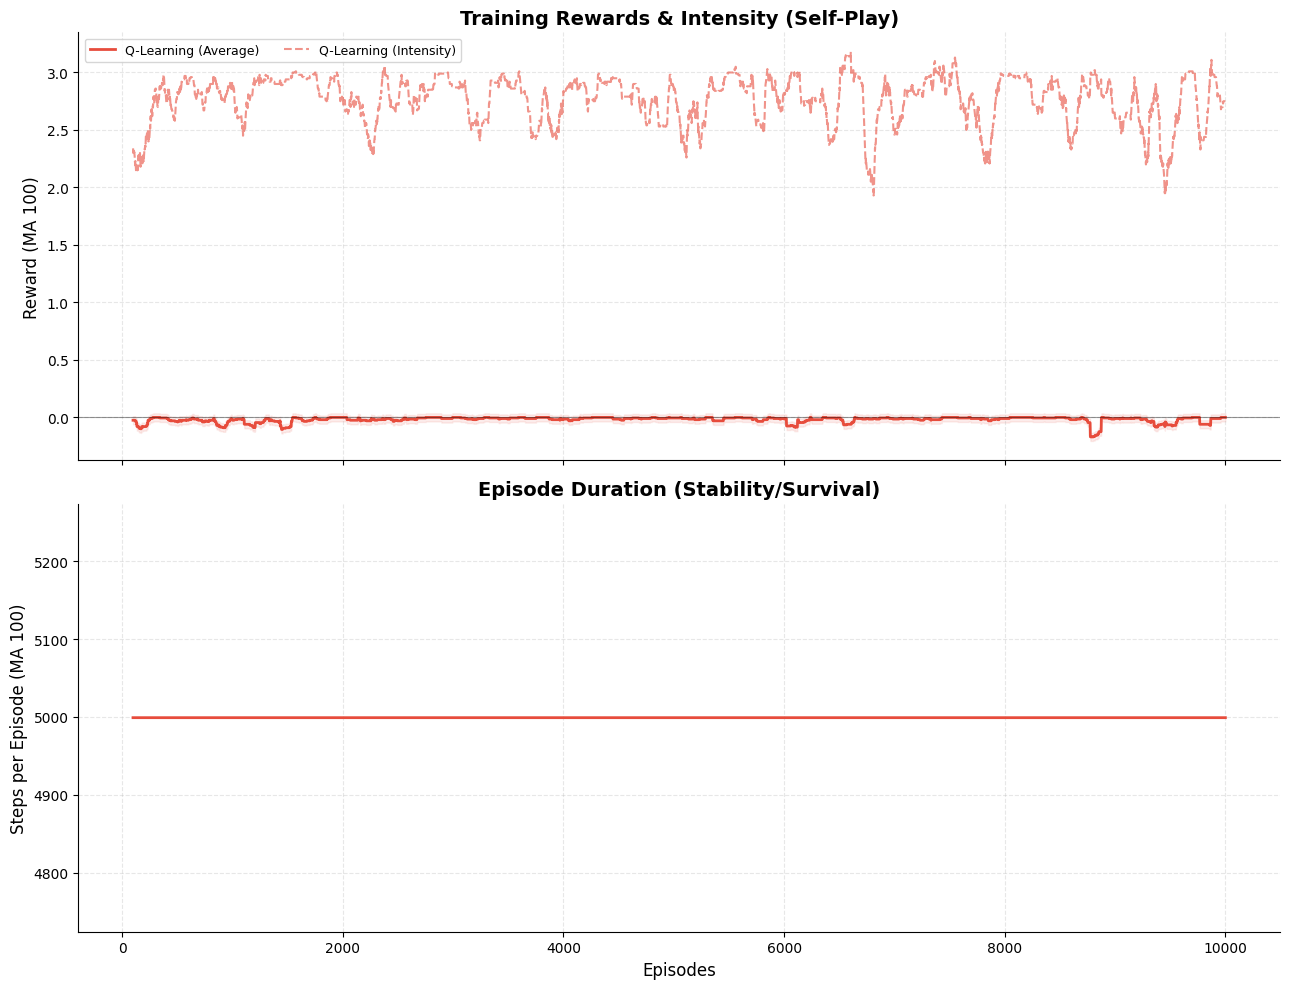

In [76]:
plot_training_curves(
    training_histories,
    f"plots/{AGENT_TO_TRAIN}_training_curves.png",
    window=100,
)


# Multi-Agent Evaluation & Tournament

### Loading Checkpoints & Running Evaluation

Before evaluation, we load the saved weights for each trained agent from the `checkpoints/` directory. If a checkpoint is missing, the agent will play with its initial weights (zeros), which is effectively random behavior.

In [65]:
for name, agent in agents.items():
    checkpoint_path = get_path(name)
    if checkpoint_path.exists():
        agent.load(str(checkpoint_path))
    else:
        print(f"Warning: Missing checkpoint for {name}")


After individual pre-training against Atari's built-in AI, we move on to **head-to-head evaluation** between our agents.

**PettingZoo Environment**: unlike Gymnasium (single player vs built-in AI), PettingZoo (`tennis_v3`) allows **two Python agents** to play against each other. The same preprocessing wrappers are applied (grayscale, resize to 84×84, 4-frame stacking) via **SuperSuit**.

**Match Protocol**: each matchup is played over **two legs** with swapped positions (`first_0` / `second_0`) to eliminate any side-of-court advantage. Results are tallied as wins, losses, and draws.

In [66]:
def run_match(
    env: tennis_v3.env,
    agent_first: Agent,
    agent_second: Agent,
    episodes: int = 10,
    max_steps: int = 4000,
) -> dict[str, int]:
    """Run head-to-head matches between two agents and count wins/draws."""
    wins = {"first": 0, "second": 0, "draw": 0}

    for _ep in range(episodes):
        env.reset()
        rewards = {"first_0": 0.0, "second_0": 0.0}

        for step_idx, agent_id in enumerate(env.agent_iter()):
            if step_idx >= max_steps:
                break

            obs, reward, termination, truncation, _info = env.last()
            done = termination or truncation
            rewards[agent_id] += float(reward)

            if done:
                action = None
            else:
                current_agent = agent_first if agent_id == "first_0" else agent_second
                action = current_agent.get_action(np.asarray(obs), epsilon=0.0)

            env.step(action)

        if rewards["first_0"] > rewards["second_0"]:
            wins["first"] += 1
        elif rewards["second_0"] > rewards["first_0"]:
            wins["second"] += 1
        else:
            wins["draw"] += 1

    return wins


## Evaluation against the Random Agent (Baseline)

To quantify whether our agents have actually learned, we first evaluate them against the **Random agent** baseline. A properly trained agent should achieve a **win rate significantly above 50%** against a random opponent.

Each agent plays **two legs** (one in each position) for a total of 20 episodes. Only decisive matches (excluding draws) are counted in the win rate calculation.

In [67]:
def evaluate_vs_random(
    agents: dict[str, Agent],
    random_agent_name: str = "Random",
    episodes_per_leg: int = 10,
) -> dict[str, float]:
    """Evaluate each agent against the specified random agent and compute win rates."""
    win_rates = {}
    env = create_env()
    agent_random = agents[random_agent_name]

    for name, agent in agents.items():
        if name == random_agent_name:
            continue

        leg1 = run_match(env, agent, agent_random, episodes=episodes_per_leg)
        leg2 = run_match(env, agent_random, agent, episodes=episodes_per_leg)

        total_wins = leg1["first"] + leg2["second"]
        total_matches = (episodes_per_leg * 2) - (leg1["draw"] + leg2["draw"])

        if total_matches == 0:
            win_rates[name] = 0.5
        else:
            win_rates[name] = total_wins / total_matches

        print(
            f"{name} vs {random_agent_name}: {total_wins} wins out of {total_matches} decisive matches (Win rate: {win_rates[name]:.1%})",
        )

    env.close()
    return win_rates


def plot_evaluation_results(
    random_win_rates: dict[str, float],
    save_path: str = "plots/evaluation_results.png",
) -> None:
    """Plot evaluation results: bar chart of win rates against Random agent."""
    agent_names = list(random_win_rates.keys())
    rates_pct = [random_win_rates[n] * 100 for n in agent_names]
    colors = [AGENT_COLORS.get(n, "#7f8c8d") for n in agent_names]

    fig, ax = plt.subplots(figsize=(8, 6))

    x = np.arange(len(agent_names))
    bars = ax.bar(x, rates_pct, color=colors, edgecolor="white", width=0.6)

    ax.set_xticks(x)
    ax.set_xticklabels(agent_names, rotation=30, ha="right", fontsize=11)
    ax.set_ylabel("Win Rate (%)", fontsize=12)
    ax.set_title("Win Rate vs Random Baseline", fontsize=14, fontweight="bold")
    ax.set_ylim(0, 110)
    ax.axhline(
        y=50,
        color="gray",
        linestyle="--",
        linewidth=1.2,
        alpha=0.7,
        label="50 % baseline",
    )
    ax.legend(fontsize=10, loc="upper right")
    ax.grid(axis="y", alpha=0.3, linestyle="--")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    for bar, wr in zip(bars, rates_pct, strict=False):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 2,
            f"{wr:.1f} %",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
        )

    fig.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


In [68]:
print("Evaluation against the Random agent")
win_rates_vs_random = evaluate_vs_random(
    agents,
    random_agent_name="Random",
    episodes_per_leg=10,
)


Evaluation against the Random agent


ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 128 is different from 28224)

TypeError: 'float' object is not subscriptable

TypeError: 'float' object is not subscriptable

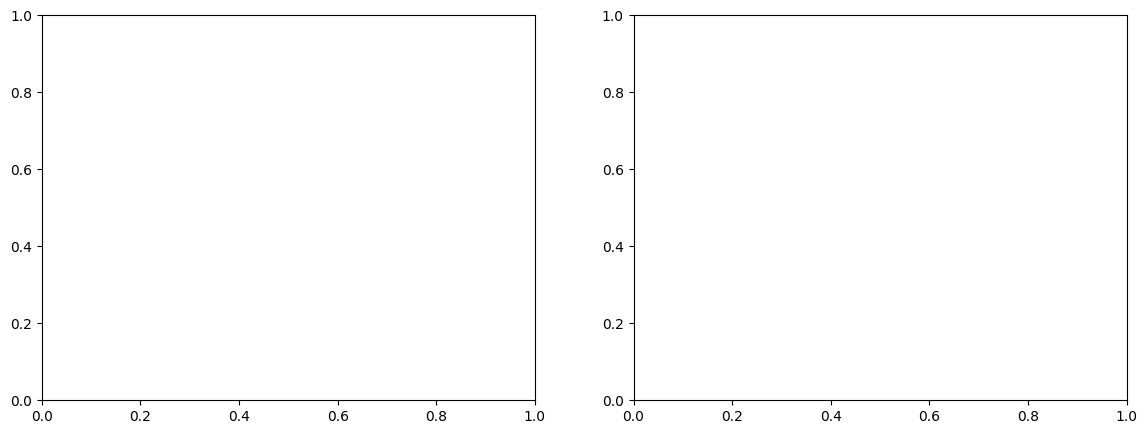

In [ ]:
plot_evaluation_results(
    win_rates_vs_random,
    save_path="plots/evaluation_results.png",
)


## Full Round-Robin Tournament

All agents play a **round-robin tournament** where each pair faces off in both positions (`first_0` / `second_0`).

The resulting $n \times n$ matchup matrix is analyzed with:
- **Aggregated ranking**: wins from both positions are combined for each agent
- **Binomial significance test** ($H_0: p = 0.5$): determines whether the win rate for each matchup is statistically different from a coin flip

In [ ]:
def run_all_matchups(
    agents: dict[str, Agent],
    episodes_per_leg: int = 20,
) -> tuple[np.ndarray, list[str]]:
    """Run round-robin matches between all pairs of agents and return the matchup matrix."""
    env = create_env()
    names = [name for name in agents if name != "Random"]
    n = len(names)
    matrix = np.full((n, n), np.nan)

    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            result = run_match(
                env,
                agents[names[i]],
                agents[names[j]],
                episodes=episodes_per_leg,
            )
            matrix[i, j] = result["first"]

    env.close()
    return matrix, names


def plot_matchup_matrix(
    matrix: np.ndarray,
    agent_names: list[str],
    episodes_per_leg: int = 20,
    save_path: str = "plots/championship_matrix.png",
) -> None:
    """Plot the matchup matrix as a heatmap with win counts and percentages."""
    n = len(agent_names)
    pct_matrix = matrix / episodes_per_leg * 100

    fig, ax = plt.subplots(figsize=(8, 7))
    masked = np.ma.array(pct_matrix, mask=np.isnan(pct_matrix))
    cmap = plt.get_cmap("RdYlGn").copy()
    cmap.set_bad(color="#f0f0f0")

    im = ax.imshow(masked, cmap=cmap, vmin=0, vmax=100, aspect="equal")

    ax.set_xticks(np.arange(n))
    ax.set_yticks(np.arange(n))
    ax.set_xticklabels(agent_names, rotation=45, ha="right", fontsize=10)
    ax.set_yticklabels(agent_names, fontsize=10)
    ax.set_xlabel("Opponent (second_0)", fontsize=11)
    ax.set_ylabel("Agent (first_0)", fontsize=11)
    ax.set_title("Championship Matchup Matrix", fontsize=14, fontweight="bold", pad=12)

    for i in range(n):
        for j in range(n):
            if i == j:
                ax.text(j, i, "—", ha="center", va="center", color="#aaa", fontsize=14)
            else:
                wins = int(matrix[i, j])
                pct = pct_matrix[i, j]
                txt_color = "white" if pct > 70 or pct < 30 else "black"
                ax.text(
                    j,
                    i,
                    f"{wins}\n({pct:.0f} %)",
                    ha="center",
                    va="center",
                    color=txt_color,
                    fontsize=9,
                    fontweight="bold",
                    linespacing=1.4,
                )

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(f"Win Rate (%) — {episodes_per_leg} eps per matchup", fontsize=10)
    cbar.set_ticks([0, 25, 50, 75, 100])
    cbar.set_ticklabels(["0 %", "25 %", "50 %", "75 %", "100 %"])

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


In [ ]:
matchup_matrix, tournament_names = run_all_matchups(agents, episodes_per_leg=20)


KeyboardInterrupt: 

In [ ]:
plot_matchup_matrix(matchup_matrix, tournament_names, episodes_per_leg=20)


NameError: name 'matchup_matrix' is not defined

# Conclusion

This project implemented and compared five Reinforcement Learning agents on Atari Tennis:

| Agent | Type | Policy | Update Rule |
|-------|------|--------|-------------|
| **Random** | Baseline | Uniform random | None |
| **SARSA** | TD(0), on-policy | ε-greedy | $W_a \leftarrow W_a + \alpha \cdot (r + \gamma \hat{q}(s', a') - \hat{q}(s, a)) \cdot \phi(s)$ |
| **Q-Learning** | TD(0), off-policy | ε-greedy | $W_a \leftarrow W_a + \alpha \cdot (r + \gamma \max_{a'} \hat{q}(s', a') - \hat{q}(s, a)) \cdot \phi(s)$ |
| **Monte Carlo** | First-visit MC | ε-greedy | $W_a \leftarrow W_a + \alpha \cdot (G_t - \hat{q}(s, a)) \cdot \phi(s)$ |
| **DQN** | Deep Q-Network | ε-greedy | Neural network (MLP 256→256) with experience replay and target network |

**Architecture**:
- **Linear agents** (SARSA, Q-Learning, Monte Carlo): $\hat{q}(s, a; \mathbf{W}) = \mathbf{W}_a^\top \phi(s)$ with $\phi(s) \in \mathbb{R}^{28\,224}$ (4 grayscale 84×84 frames, normalized)
- **DQN**: MLP network (28,224 → 256 → 256 → 18) trained with Adam optimizer, Huber loss, and periodic target network sync

**Methodology**:
1. **Sequential pre-training** of all agents against Atari's built-in AI (3,000 episodes, ε decaying linearly from 1.0 to 0.05 over 500k steps)
2. **Evaluation vs Random** to validate learning (expected win rate > 50%)
3. **Evaluation vs Atari AI** with per-episode reward statistics (mean ± std) and distributions
4. **Full round-robin tournament** via PettingZoo (20 episodes per matchup per position) with statistical significance analysis